### Вводные данные

In [2]:
import stage1_functions as my_funcs
import pandas as pd

file_path = 'путь до моего документа с данными'
sheets = my_funcs.load_sheets(file_path)

# Суммарный коэффициент рождаемости (1,4 и тд)
tfr = sheets['СКР']

# Региональный материнский капитал (В рублях)
rmc1, rmc2, rmc3 = sheets['РМК1'], sheets['РМК2'], sheets['РМК3']

# Доля городского населения (Доля: 0-1)
urban_share = sheets['Доля Городского населения-Ср']

# Показатели брачности (от 1 и более - нормированный показатель)
marriage_rate, divorce_rate = sheets['Коэф. брачности'], sheets['Коэф. разводимости']

# Среднедушевые доходы населения (В рублях)
income_in_reg = sheets['Среднедушевые доходы']

# Соотношение среднедушевых доходов населения к прожиточному минимуму (нормировано)
income_index = sheets['Соотношение СДД к ПМ']

# Уровень безработицы (В процентах)
unemployment = sheets['Уровень безработицы']

# Доля женщин фертильного возраста (Доля: 0-1)
fert_women = sheets['Доля женщин ферт возраста']

# Ожидаемая продолжительность жизни. В 2024 году перестали публиковать (В годах)
lifespan = sheets['Ожидаемая продолжительность жиз']

# Детская смертность. Зафиксирован структурный сдвиг в 2018, нет данных за 2024
child_mortality = sheets['Умершие дети до 1 года на тыс']

# Дошкольное образование  (В процентах)
preschool_coverage = sheets['Охват дошкольным образованием']

### Дата инжениринг

In [4]:
# Доля регионального маткапитала в среднедушевых доходах
rmc1_to_income = my_funcs.get_relative_metric(rmc1, income_in_reg)
rmc2_to_income = my_funcs.get_relative_metric(rmc2, income_in_reg)
rmc3_to_income = my_funcs.get_relative_metric(rmc3, income_in_reg)

# Соотношение разводов к бракам
divorce_to_marriage = my_funcs.get_relative_metric(divorce_rate, marriage_rate)

# Перевод из процентов в доли
# Для безработицы
unemployment = unemployment.set_index('Регион') / 100
unemployment = unemployment.reset_index()

# Для дошкольного охвата
preschool_coverage = preschool_coverage.set_index('Регион') / 100
preschool_coverage = preschool_coverage.reset_index()

### Агрегируем в единый панельный датафрейм

In [6]:
from functools import reduce

# В датасетах фигурируют поля с агрегацией, которые нам не нужны
exclude = [r'Факт', r'Сумма']

# Сборка всего того, что мы импортировали
datasets = [
    (tfr, 'СКР'), (rmc1_to_income, 'РМК_1'), (rmc2_to_income, 'РМК_2'), (rmc3_to_income, 'РМК_3'),
    (urban_share, 'Доля городского населения'), (marriage_rate, 'Коэффициент брачности'), 
    (divorce_rate, 'Коэффициент разводимости'), (divorce_to_marriage, 'Соотношение браков к разводам'), 
    (unemployment, 'Уровень безработицы'), (lifespan, 'Ожидаемая продолжительность жизни'),
    (fert_women, 'Доля женщин фертильного возраста'), (child_mortality, 'Детская смертность'), 
    (preschool_coverage, 'Покрытие дошкольным образованием')
]

# Меняем их формат из wide в long
regional_dfs = [
    my_funcs.to_long(df, name, exclude_patterns=exclude) for df, name in datasets
]

# Соединяем
panel_df = reduce(
    lambda l, r: pd.merge(l, r, on=['region', 'year'], how='outer'), regional_dfs
)

In [7]:
panel_df[
    panel_df['year'].between(2020, 2025)
    ].head()

,region,year,СКР,РМК_1,РМК_2,РМК_3,Доля городского населения,Коэффициент брачности,Коэффициент разводимости,Соотношение браков к разводам,Уровень безработицы,Ожидаемая продолжительность жизни,Доля женщин фертильного возраста,Детская смертность,Покрытие дошкольным образованием
30,Алтайский край,2020,1.425,0.0,0.0,2.217185,0.577191,5.2,4.5,0.865385,0.059,69.45,0.424659,4.8,0.692
31,Алтайский край,2021,1.407,0.0,0.0,2.109614,0.580565,6.1,4.8,0.786885,0.056,67.79,0.424023,4.6,0.763
32,Алтайский край,2022,1.345,0.0,0.0,1.901371,0.582771,7.3,5.0,0.684932,0.038,69.96,0.424057,4.0,0.791
33,Алтайский край,2023,1.305,0.0,0.0,2.202465,0.584009,6.5,5.1,0.784615,0.034,70.77,0.423096,3.9,0.846
34,Алтайский край,2024,1.236,0.0,0.0,1.961633,0.586070,6.5,4.8,0.738462,0.034,NaN,0.423381,3.7,0.855


### Анализ пропущенных значений

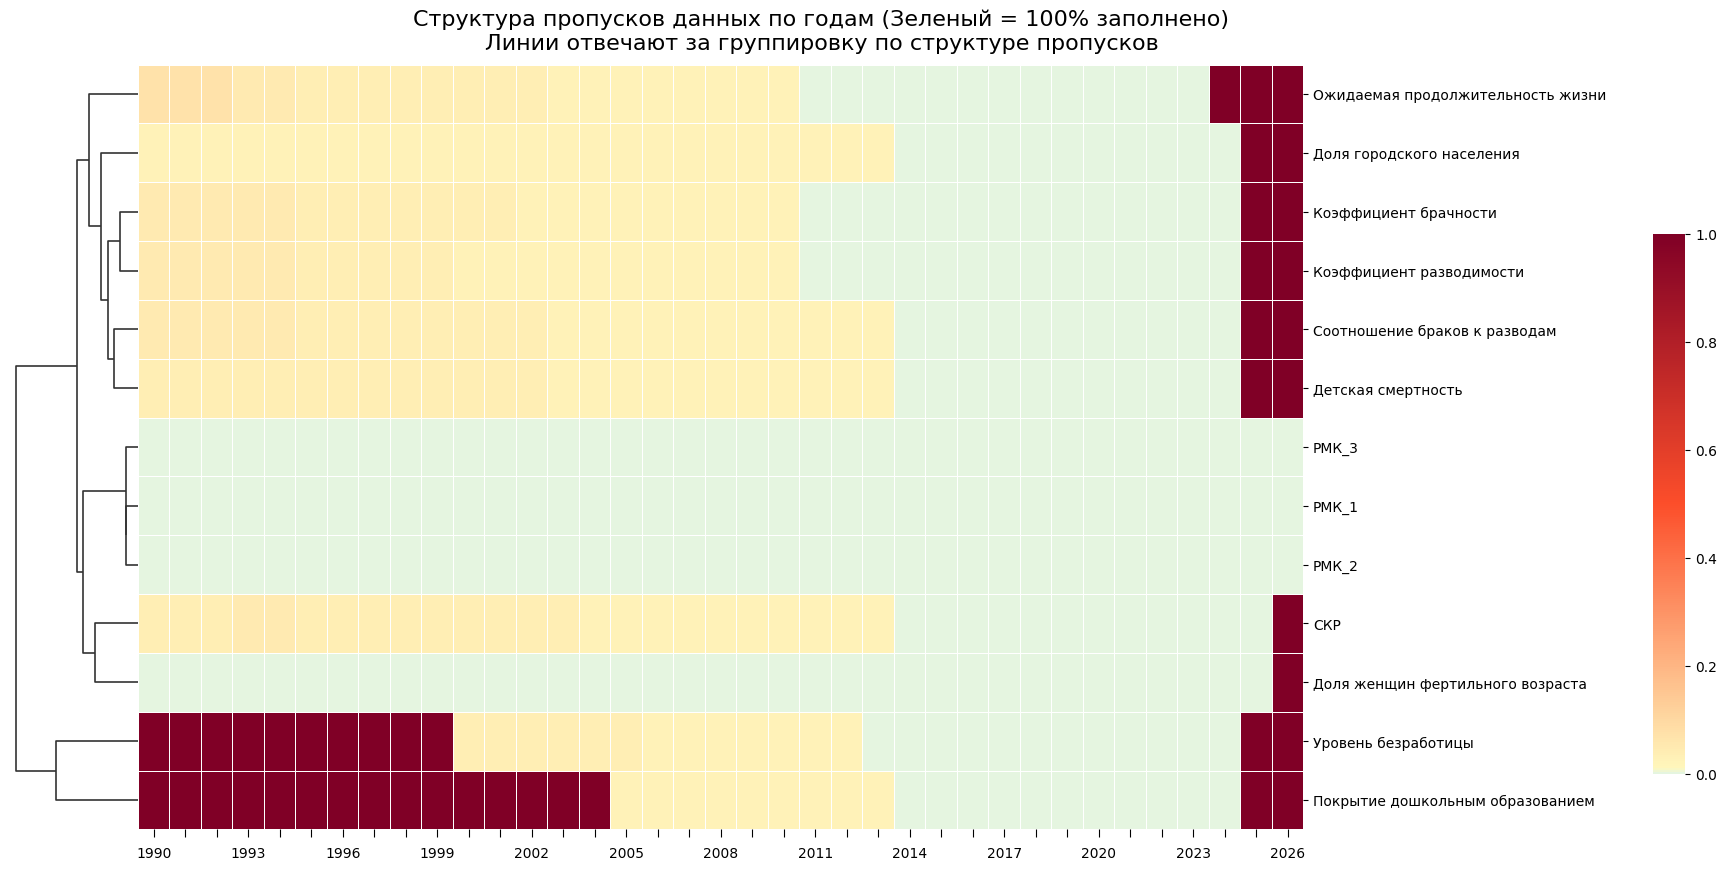

In [9]:
# В РМК пропусков нет - там просто не было выплат, поэтому заполняем нулями места, где РМК нет
panel_df[['РМК_1', 'РМК_2', 'РМК_3']] = panel_df[['РМК_1', 'РМК_2', 'РМК_3']].fillna(0)

# Далее уже выводим и смотрим, где есть пропуски и в каком соотношении
my_funcs.plot_missingness(df=panel_df)

### Обработка пропущенных значений

Продолжим приводить данные к формату под линейную регрессию. Внесем изменения:
- Все показатели, кроме исключений, будут взяты с лагом 1
- Ожидаемая продолжительность жизни - лаг 2 (Избегаем интерполяций)
- Удаляем строки датафрейма с пропущенной целевой переменной - это 10 лет для 4 субъектов РФ (Меньше 5% наблюдений)
- Берем срез с 2006 года как наиболее полный и вплоть до 2025 года (последний известный СКР)

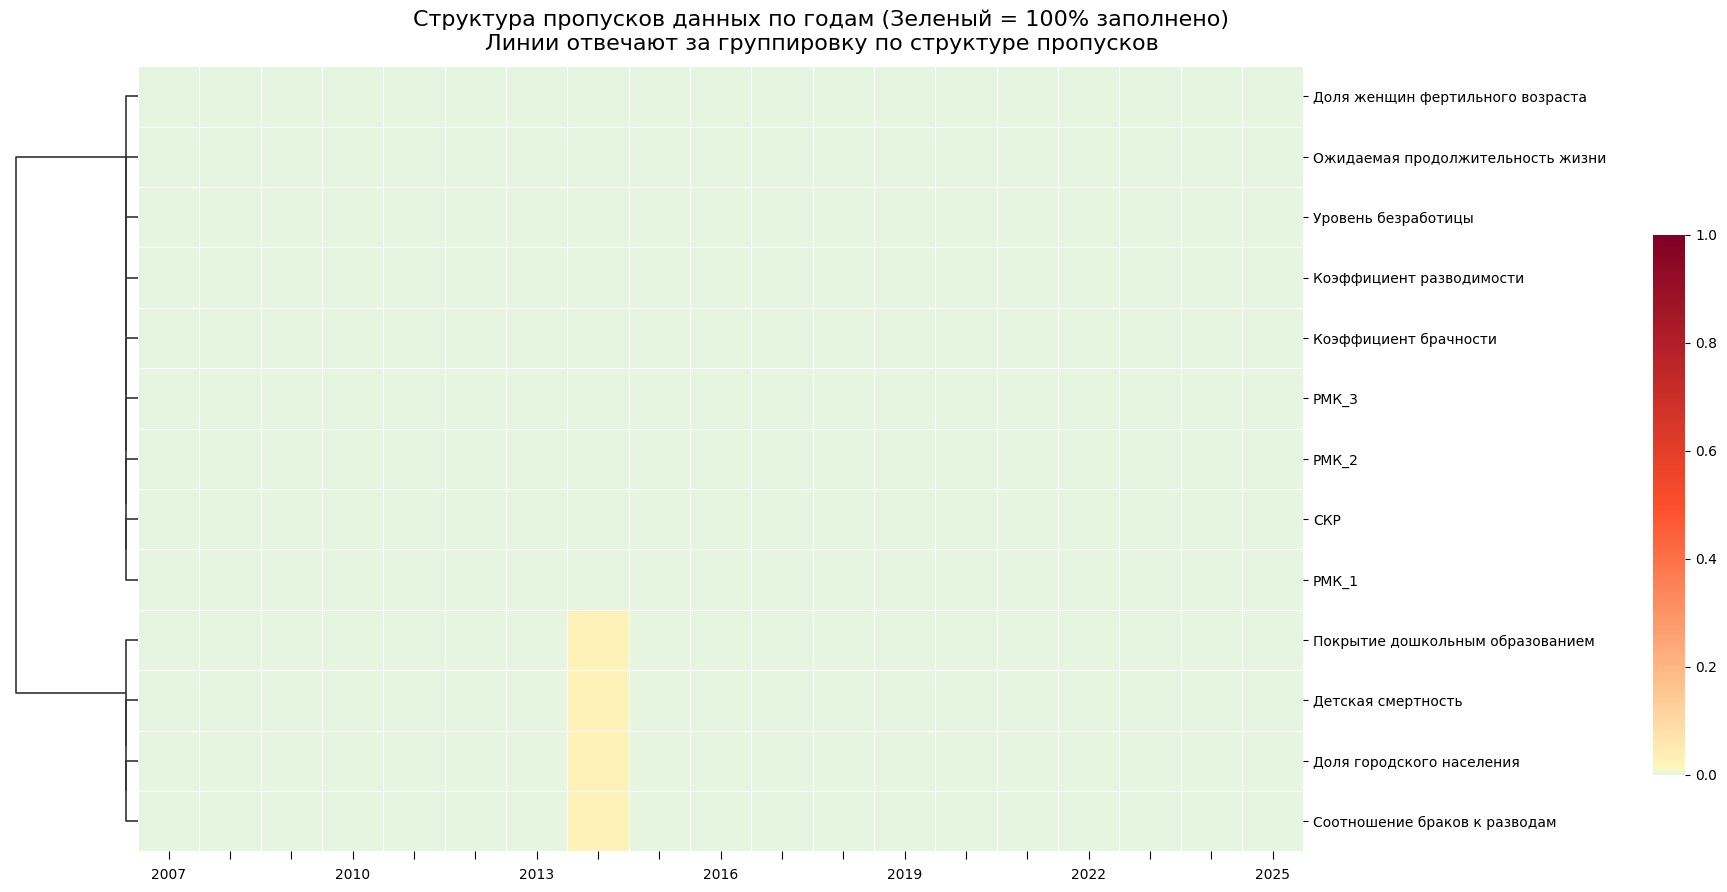

In [12]:
# Сдвигаем на выбранное количество лагов
df_lagged = my_funcs.shift_panel_by_lags(
    df=panel_df, group_col="region", time_col="year",
    exclude_cols=["region", "year", "СКР"], default_lag=1, 
    special_col="Ожидаемая продолжительность жизни", special_lag=2
)

# Возвращаем столбец регионов (технический момент)
df_lagged['region'] = panel_df['region'].values

# Исключаем наблюдения, где есть пропуски по СКР
df_lagged = df_lagged.dropna(subset=['СКР'])

# Ограничиваем рассматриваемый временной период
df_lagged = df_lagged[df_lagged['year'].between(2007, 2026)]

my_funcs.plot_missingness(df=df_lagged)

#### Формируем эконометрическую модель

In [14]:
import statsmodels.api as sm
import numpy as np

# 1. Устанавливаем индекс панели (обязательно для PanelOLS!)
df_lagged = df_lagged.set_index(['region', 'year'])

# 2. Отделяем Y (логарифмируем СКР для интерпретируемости коэффициентов)
y = np.log(df_lagged['СКР'] + 1e-6)

# 3. Регрессоры - все остальное. Помним про константу
X = df_lagged.drop(['СКР', 'Коэффициент брачности', 'Коэффициент разводимости'], axis=1)
X = sm.add_constant(X)

In [15]:
from linearmodels.panel import PanelOLS

# Варианты моделей
model1 = PanelOLS(y, X, entity_effects=True, time_effects=True) 
model2 = PanelOLS(y, X, entity_effects=True, time_effects=False) 
model3 = PanelOLS(y, X, entity_effects=True, time_effects=False)

# Fit все сразу
results1 = model1.fit(cov_type='clustered', cluster_entity=True)
results2 = model2.fit(cov_type='clustered', cluster_entity=True)
results3 = model3.fit(cov_type='kernel')

/Users/kolobrovskiy/miniconda3/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/Users/kolobrovskiy/miniconda3/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/Users/kolobrovskiy/miniconda3/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [16]:
print(results1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    СКР   R-squared:                        0.1423
Estimator:                   PanelOLS   R-squared (Between):             -0.0551
No. Observations:                1599   R-squared (Within):               0.0326
Date:                Sun, May 03 2026   R-squared (Overall):             -0.0262
Time:                        13:03:19   Log-likelihood                    2659.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      24.653
Entities:                          85   P-value                           0.0000
Avg Obs:                       18.812   Distribution:                 F(10,1486)
Min Obs:                       11.000                                           
Max Obs:                       19.000   F-statistic (robust):             6.1901
                            

In [17]:
print(results2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    СКР   R-squared:                        0.5182
Estimator:                   PanelOLS   R-squared (Between):             -0.0987
No. Observations:                1599   R-squared (Within):               0.5182
Date:                Sun, May 03 2026   R-squared (Overall):              0.0878
Time:                        13:03:19   Log-likelihood                    1947.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      161.75
Entities:                          85   P-value                           0.0000
Avg Obs:                       18.812   Distribution:                 F(10,1504)
Min Obs:                       11.000                                           
Max Obs:                       19.000   F-statistic (robust):             62.352
                            

In [18]:
print(results3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    СКР   R-squared:                        0.5182
Estimator:                   PanelOLS   R-squared (Between):             -0.0987
No. Observations:                1599   R-squared (Within):               0.5182
Date:                Sun, May 03 2026   R-squared (Overall):              0.0878
Time:                        13:03:19   Log-likelihood                    1947.3
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      161.75
Entities:                          85   P-value                           0.0000
Avg Obs:                       18.812   Distribution:                 F(10,1504)
Min Obs:                       11.000                                           
Max Obs:                       19.000   F-statistic (robust):             342.43
                            

### Выводы

Итоговая модель - номер 3. Аналогичная же спецификация использовалась в статье Вакуленко с аналогичным значимым отрицательным коэффициентом при покрытии дошкольным образованием и положительным РМК3. Аналогичная ковариационная матрица Дрисколла-Крея использовалась для учета пространственных эффектов. Результаты этой модели берутся в качестве итоговой спецификации и будут использоваться на этапе III.